# Module 3: Simplified Polynesian Information Source

* DS 5001
* Clay Harris jbm2rt

This notebook creates an information source using Simplified Polynesian, implementing a Babel library permutation space with weighted character generation.

# Set Up

In [1]:
import pandas as pd
import numpy as np
import itertools
import math

In [2]:
np.random.seed(42)  # For reproducibility

# Define the Simplified Polynesian Alphabet

Based on Example 8 from the reading, Simplified Polynesian has the following letter frequencies:

| Letter | Probability |
|--------|-------------|
| p      | 1/8         |
| t      | 1/4         |
| k      | 1/8         |
| a      | 1/4         |
| i      | 1/8         |
| u      | 1/8         |

The per-letter entropy is H(P) = 2.5 bits

In [3]:
# Define alphabet and probabilities
letters = ['p', 't', 'k', 'a', 'i', 'u']
probabilities = [1/8, 1/4, 1/8, 1/4, 1/8, 1/8]

# Create a DataFrame for the alphabet
alphabet_df = pd.DataFrame({
    'letter': letters,
    'probability': probabilities
})

alphabet_df

,letter,probability
0,p,0.125
1,t,0.250
2,k,0.125
3,a,0.250
4,i,0.125
5,u,0.125


## Verify Entropy Calculation

In [4]:
# Calculate entropy
entropy = -sum([p * math.log2(p) for p in probabilities])
print(f"Per-letter entropy H(P) = {entropy:.2f} bits")

Per-letter entropy H(P) = 2.50 bits


# Generate Babel Library Permutation Space

Create all possible 7-letter words using the Simplified Polynesian alphabet. Note that spaces separate words but are not part of the character set itself.

## Calculate Library Size

With 6 letters and message length of 7, the total number of possible words is:

In [14]:
message_length = 7
alphabet_size = len(letters)
library_size = alphabet_size ** message_length

print(f"Alphabet size: {alphabet_size}")
print(f"Message length: {message_length}")
print(f"Total possible words: {library_size:,}")

Alphabet size: 6
Message length: 7
Total possible words: 279,936


## Create the Babel Library using Pandas

Generate all possible 7-letter combinations and store them in a DataFrame.

In [15]:
# Generate all possible 7-letter combinations
all_combinations = itertools.product(letters, repeat=message_length)

# Create DataFrame with word_id and the word itself
babel_library = pd.DataFrame([
    {'word_id': i, 'word': ''.join(combo)} 
    for i, combo in enumerate(all_combinations)
])

print(f"Generated {len(babel_library):,} words")
babel_library.head(10)

Generated 279,936 words


,word_id,word
0,0,ppppppp
1,1,ppppppt
2,2,ppppppk
3,3,ppppppa
4,4,ppppppi
5,5,ppppppu
6,6,ppppptp
7,7,ppppptt
8,8,ppppptk
9,9,pppppta


## Add Position Columns

Split each word into its individual character positions for analysis:

In [16]:
# Split words into individual character positions
for i in range(message_length):
    babel_library[f'pos_{i}'] = babel_library['word'].str[i]

babel_library.head(10)

,word_id,word,pos_0,pos_1,pos_2,pos_3,pos_4,pos_5,pos_6
0,0,ppppppp,p,p,p,p,p,p,p
1,1,ppppppt,p,p,p,p,p,p,t
2,2,ppppppk,p,p,p,p,p,p,k
3,3,ppppppa,p,p,p,p,p,p,a
4,4,ppppppi,p,p,p,p,p,p,i
5,5,ppppppu,p,p,p,p,p,p,u
6,6,ppppptp,p,p,p,p,p,t,p
7,7,ppppptt,p,p,p,p,p,t,t
8,8,ppppptk,p,p,p,p,p,t,k
9,9,pppppta,p,p,p,p,p,t,a


## Calculate Word Probabilities

Each word's probability is the product of its constituent letter probabilities:

In [17]:
# Create a dictionary for quick probability lookup
prob_dict = dict(zip(letters, probabilities))

# Calculate probability for each word
def calculate_word_probability(word):
    return np.prod([prob_dict[char] for char in word])

babel_library['probability'] = babel_library['word'].apply(calculate_word_probability)

# Verify probabilities sum to 1
total_prob = babel_library['probability'].sum()
print(f"Total probability: {total_prob:.6f}")
print(f"Verification: Should be 1.0")

babel_library.head(10)

Total probability: 1.000000
Verification: Should be 1.0


,word_id,word,pos_0,pos_1,pos_2,pos_3,pos_4,pos_5,pos_6,probability
0,0,ppppppp,p,p,p,p,p,p,p,4.768372e-07
1,1,ppppppt,p,p,p,p,p,p,t,9.536743e-07
2,2,ppppppk,p,p,p,p,p,p,k,4.768372e-07
3,3,ppppppa,p,p,p,p,p,p,a,9.536743e-07
4,4,ppppppi,p,p,p,p,p,p,i,4.768372e-07
5,5,ppppppu,p,p,p,p,p,p,u,4.768372e-07
6,6,ppppptp,p,p,p,p,p,t,p,9.536743e-07
7,7,ppppptt,p,p,p,p,p,t,t,1.907349e-06
8,8,ppppptk,p,p,p,p,p,t,k,9.536743e-07
9,9,pppppta,p,p,p,p,p,t,a,1.907349e-06


## Explore the Library

In [18]:
# Find most and least probable words
print("Most probable words:")
print(babel_library.nlargest(10, 'probability')[['word', 'probability']])
print("\nLeast probable words:")
print(babel_library.nsmallest(10, 'probability')[['word', 'probability']])

Most probable words:
          word  probability
55987  ttttttt     0.000061
55989  tttttta     0.000061
55999  tttttat     0.000061
56001  tttttaa     0.000061
56059  ttttatt     0.000061
56061  ttttata     0.000061
56071  ttttaat     0.000061
56073  ttttaaa     0.000061
56419  tttattt     0.000061
56421  tttatta     0.000061

Least probable words:
       word   probability
0   ppppppp  4.768372e-07
2   ppppppk  4.768372e-07
4   ppppppi  4.768372e-07
5   ppppppu  4.768372e-07
12  pppppkp  4.768372e-07
14  pppppkk  4.768372e-07
16  pppppki  4.768372e-07
17  pppppku  4.768372e-07
24  pppppip  4.768372e-07
26  pppppik  4.768372e-07


# Generate Random Text

Generate text by randomly selecting 7-letter words based on their probability weights. Words will be separated by spaces.

## Simple Text Generator

Generate a text of specified number of words using the unigram term frequencies:

In [19]:
def generate_polynesian_text(num_words=20):
    """
    Generate text by randomly sampling words from the Babel library
    using the probability weights.
    
    Args:
        num_words: Number of words to generate
    
    Returns:
        A string of space-separated words
    """
    # Sample words according to their probabilities
    selected_words = np.random.choice(
        babel_library['word'].values,
        size=num_words,
        p=babel_library['probability'].values
    )
    
    return ' '.join(selected_words)

# Generate sample text
sample_text = generate_polynesian_text(20)
print("Generated Simplified Polynesian text:")
print(sample_text)

Generated Simplified Polynesian text:
ptttppp tkuiaup utpppaa aiuuatt patiaup iatakti kuattui iittakk aktkttp aautakt uuatiip tkkkiat akuautu kaautui ptipikp ppuktat puaapau aakpaaa atatait attutuk


## Generate Longer Text Sample

Generate a longer text to see the patterns:

In [20]:
# Generate a longer text
long_text = generate_polynesian_text(100)
print("Longer text sample (100 words):")
print(long_text)

Longer text sample (100 words):
ptapaku kiptaap uktttip kttktpt akuuiau itkaatp itatiua apakaui iiutati ktpttat upuppai tkaauui takiuat pkkttaa ituaaai ktiitpt tktiaka tkktiia uttupta iaaauau attukta akaiutt kituktu ktptata utituat tppttpp ktupuia tupttia kuupkkt kaaatau apaktiu tpkiatt apktuaa tkipkit ttkakpt papakpu ipikiak kktuktt aapttiu autaapu aaiuaki kiputtt kpiakti kppkuka aatkaia kuaaaaa iituptt iuuiitk tttktik tptuapp aapaipu taiatkt ptpipta upiuupt tktattt ukkitia aiuaaak ipikiaa ttautpa tkkuaap apaaupu tttapka taupipi titaatu ttpkkai ttitatt itaukia tttttai ptktaat aapatkt uikaiap tiakttp puakppk ataaptp utappii itatuap akutuaa tipaaki attttkp pautuki aaiutka auttauu uaupkpa tattttp ptpautt attktut aiakipt ititupt ttaktta tattapt apktktp tiatitp iupatik kititat iktttat atititt ittkaat tiaatia iaaktui taktpaa


## Analyze Generated Text

Verify that our generated text follows the expected letter frequency distribution:

In [21]:
# Generate a large sample for analysis
large_sample = generate_polynesian_text(10000)

# Remove spaces and count letters
letters_only = large_sample.replace(' ', '')
letter_counts = pd.Series(list(letters_only)).value_counts().sort_index()

# Calculate observed frequencies
total_letters = len(letters_only)
observed_freq = letter_counts / total_letters

# Compare with expected frequencies
comparison = pd.DataFrame({
    'letter': letters,
    'expected_freq': probabilities,
    'observed_freq': [observed_freq.get(letter, 0) for letter in letters]
})

comparison['difference'] = comparison['observed_freq'] - comparison['expected_freq']

print(f"Analysis based on {total_letters:,} letters (10,000 words):")
print(comparison)

Analysis based on 70,000 letters (10,000 words):
  letter  expected_freq  observed_freq  difference
0      p          0.125       0.123457   -0.001543
1      t          0.250       0.249629   -0.000371
2      k          0.125       0.127214    0.002214
3      a          0.250       0.248386   -0.001614
4      i          0.125       0.125257    0.000257
5      u          0.125       0.126057    0.001057


## Visualize Letter Frequency Distribution

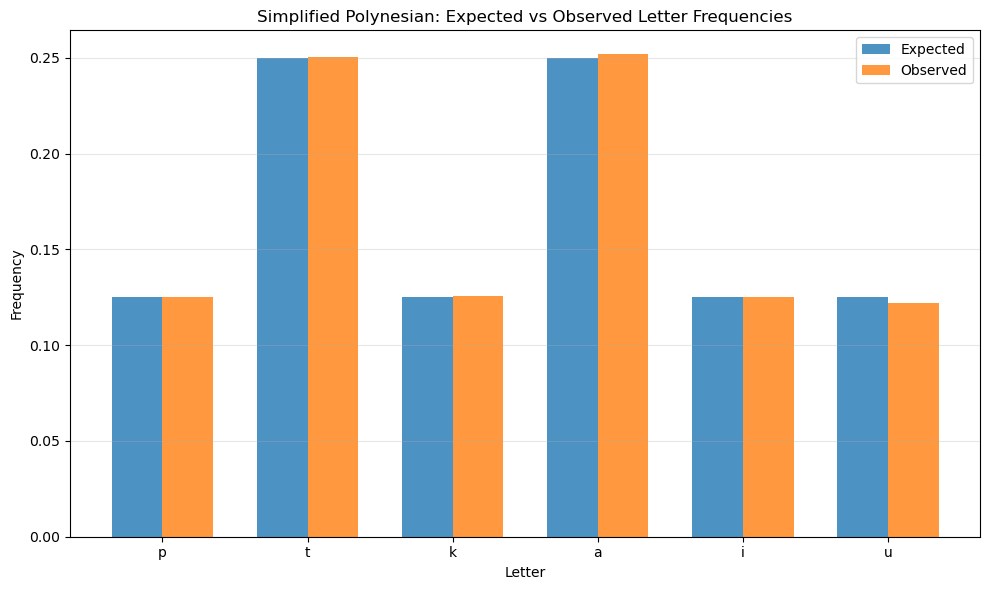

In [13]:
import matplotlib.pyplot as plt

# Create comparison plot
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(letters))
width = 0.35

ax.bar(x - width/2, comparison['expected_freq'], width, label='Expected', alpha=0.8)
ax.bar(x + width/2, comparison['observed_freq'], width, label='Observed', alpha=0.8)

ax.set_xlabel('Letter')
ax.set_ylabel('Frequency')
ax.set_title('Simplified Polynesian: Expected vs Observed Letter Frequencies')
ax.set_xticks(x)
ax.set_xticklabels(letters)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()